In [46]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-performance-dataset/Student_performance_data _.csv


<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    Student Performance Analysis
</div>


![Student Performance View](https://i.ytimg.com/vi/UM5bxbosgD8/maxresdefault.jpg)
     


## 📋 Summary About Dataset

This dataset contains detailed information about high school students’ demographics, study habits, parental involvement, extracurricular activities, and academic performance.  
The goal is to **analyze the factors that influence student success** and build a model to predict their grade outcomes.


## Executive Summary

- This project, “Student Performance Analysis,” explores how various factors—such as parental education, gender, lunch type, and test preparation—affect student outcomes in math, reading, and writing exams.

- Using data from the Kaggle Student Performance Dataset, the project applies data analysis, visualization, and machine learning techniques to uncover key patterns influencing student success.

- The overall objective was to:

- Understand demographic and socio-economic factors impacting scores.

- Visualize trends and correlations between variables.

- Build a Support Vector Machine (SVM) model to classify students into performance groups based on their average scores.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    📊 Load Dataset
</div>


In [66]:
df = pd.read_csv('/kaggle/input/students-performance-dataset/Student_performance_data _.csv')

<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    ✅ Data Info & Null Check
</div>


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [50]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [51]:
df.tail()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0
2391,3392,16,1,0,2,17.819907,13,0,2,0,0,0,1,2.140014,1.0


In [52]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    📈 Feature Distribution
</div>


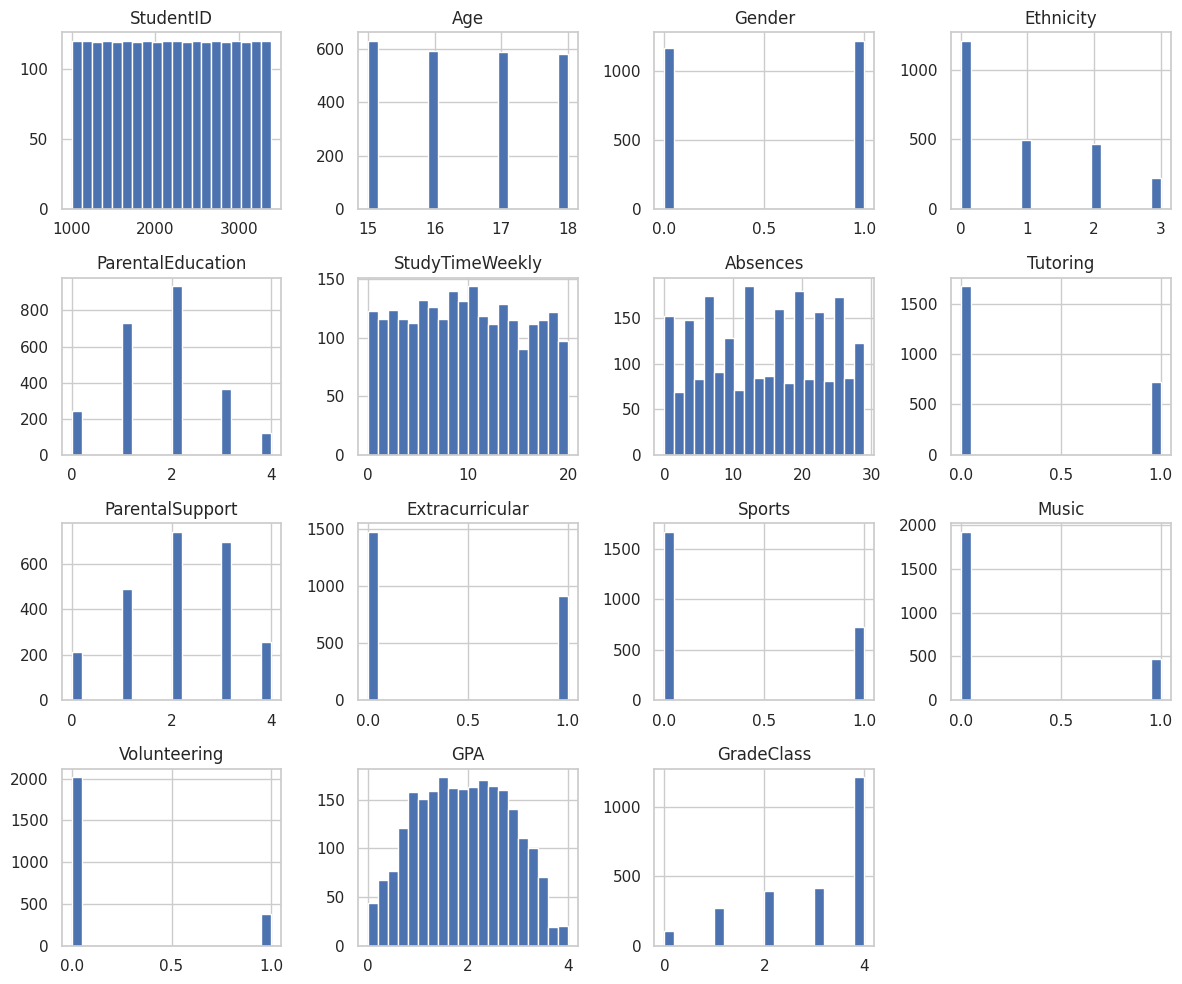

In [53]:

df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()



<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
     Define Categorical and Numerical Features
</div>



In [54]:
categorical_cols = ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 
                    'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']


for col in categorical_cols:
    print(f"{col} value counts:\n{df[col].value_counts()}\n")

Age value counts:
Age
15    630
16    593
17    587
18    582
Name: count, dtype: int64

Gender value counts:
Gender
1    1222
0    1170
Name: count, dtype: int64

Ethnicity value counts:
Ethnicity
0    1207
1     493
2     470
3     222
Name: count, dtype: int64

ParentalEducation value counts:
ParentalEducation
2    934
1    728
3    367
0    243
4    120
Name: count, dtype: int64

Tutoring value counts:
Tutoring
0    1671
1     721
Name: count, dtype: int64

ParentalSupport value counts:
ParentalSupport
2    740
3    697
1    489
4    254
0    212
Name: count, dtype: int64

Extracurricular value counts:
Extracurricular
0    1475
1     917
Name: count, dtype: int64

Sports value counts:
Sports
0    1666
1     726
Name: count, dtype: int64

Music value counts:
Music
0    1921
1     471
Name: count, dtype: int64

Volunteering value counts:
Volunteering
0    2016
1     376
Name: count, dtype: int64

GradeClass value counts:
GradeClass
4.0    1211
3.0     414
2.0     391
1.0     269
0.0 

<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
     Label encode categorical columns safely
</div>


In [55]:

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

numerical_cols = ['StudyTimeWeekly', 'Absences', 'GPA']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
     🔍 Correlation
</div>



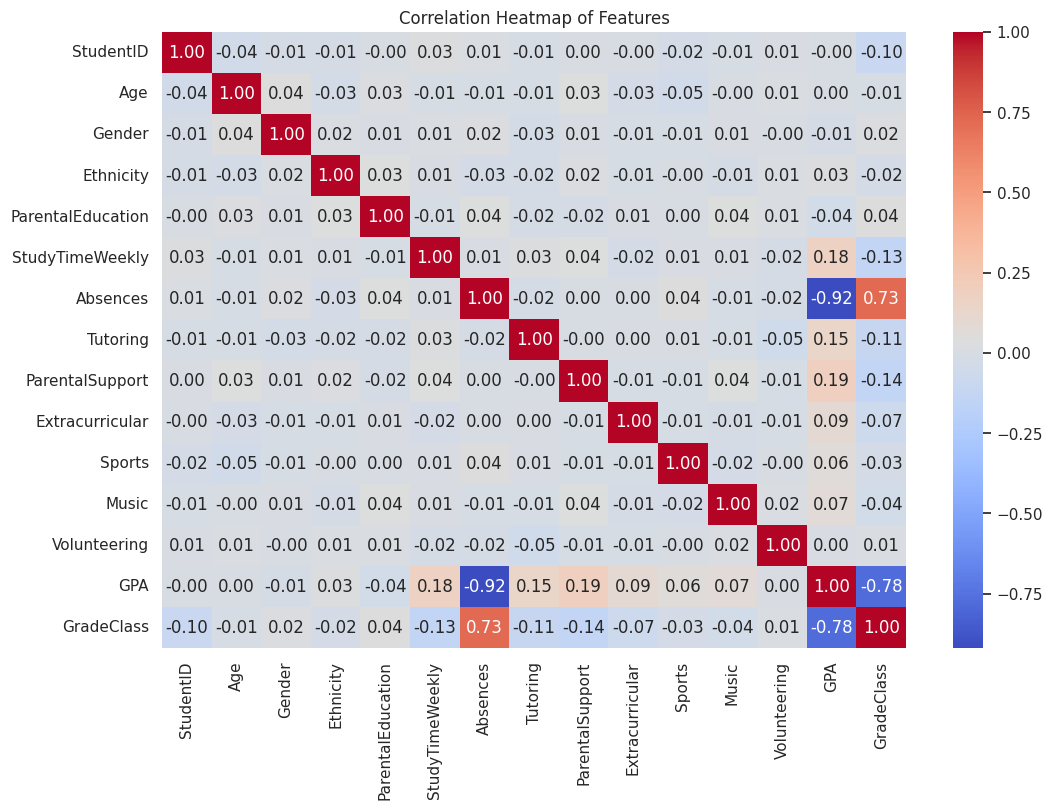

In [56]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
     📊 Categorical features vs GradeClass (countplots)
</div

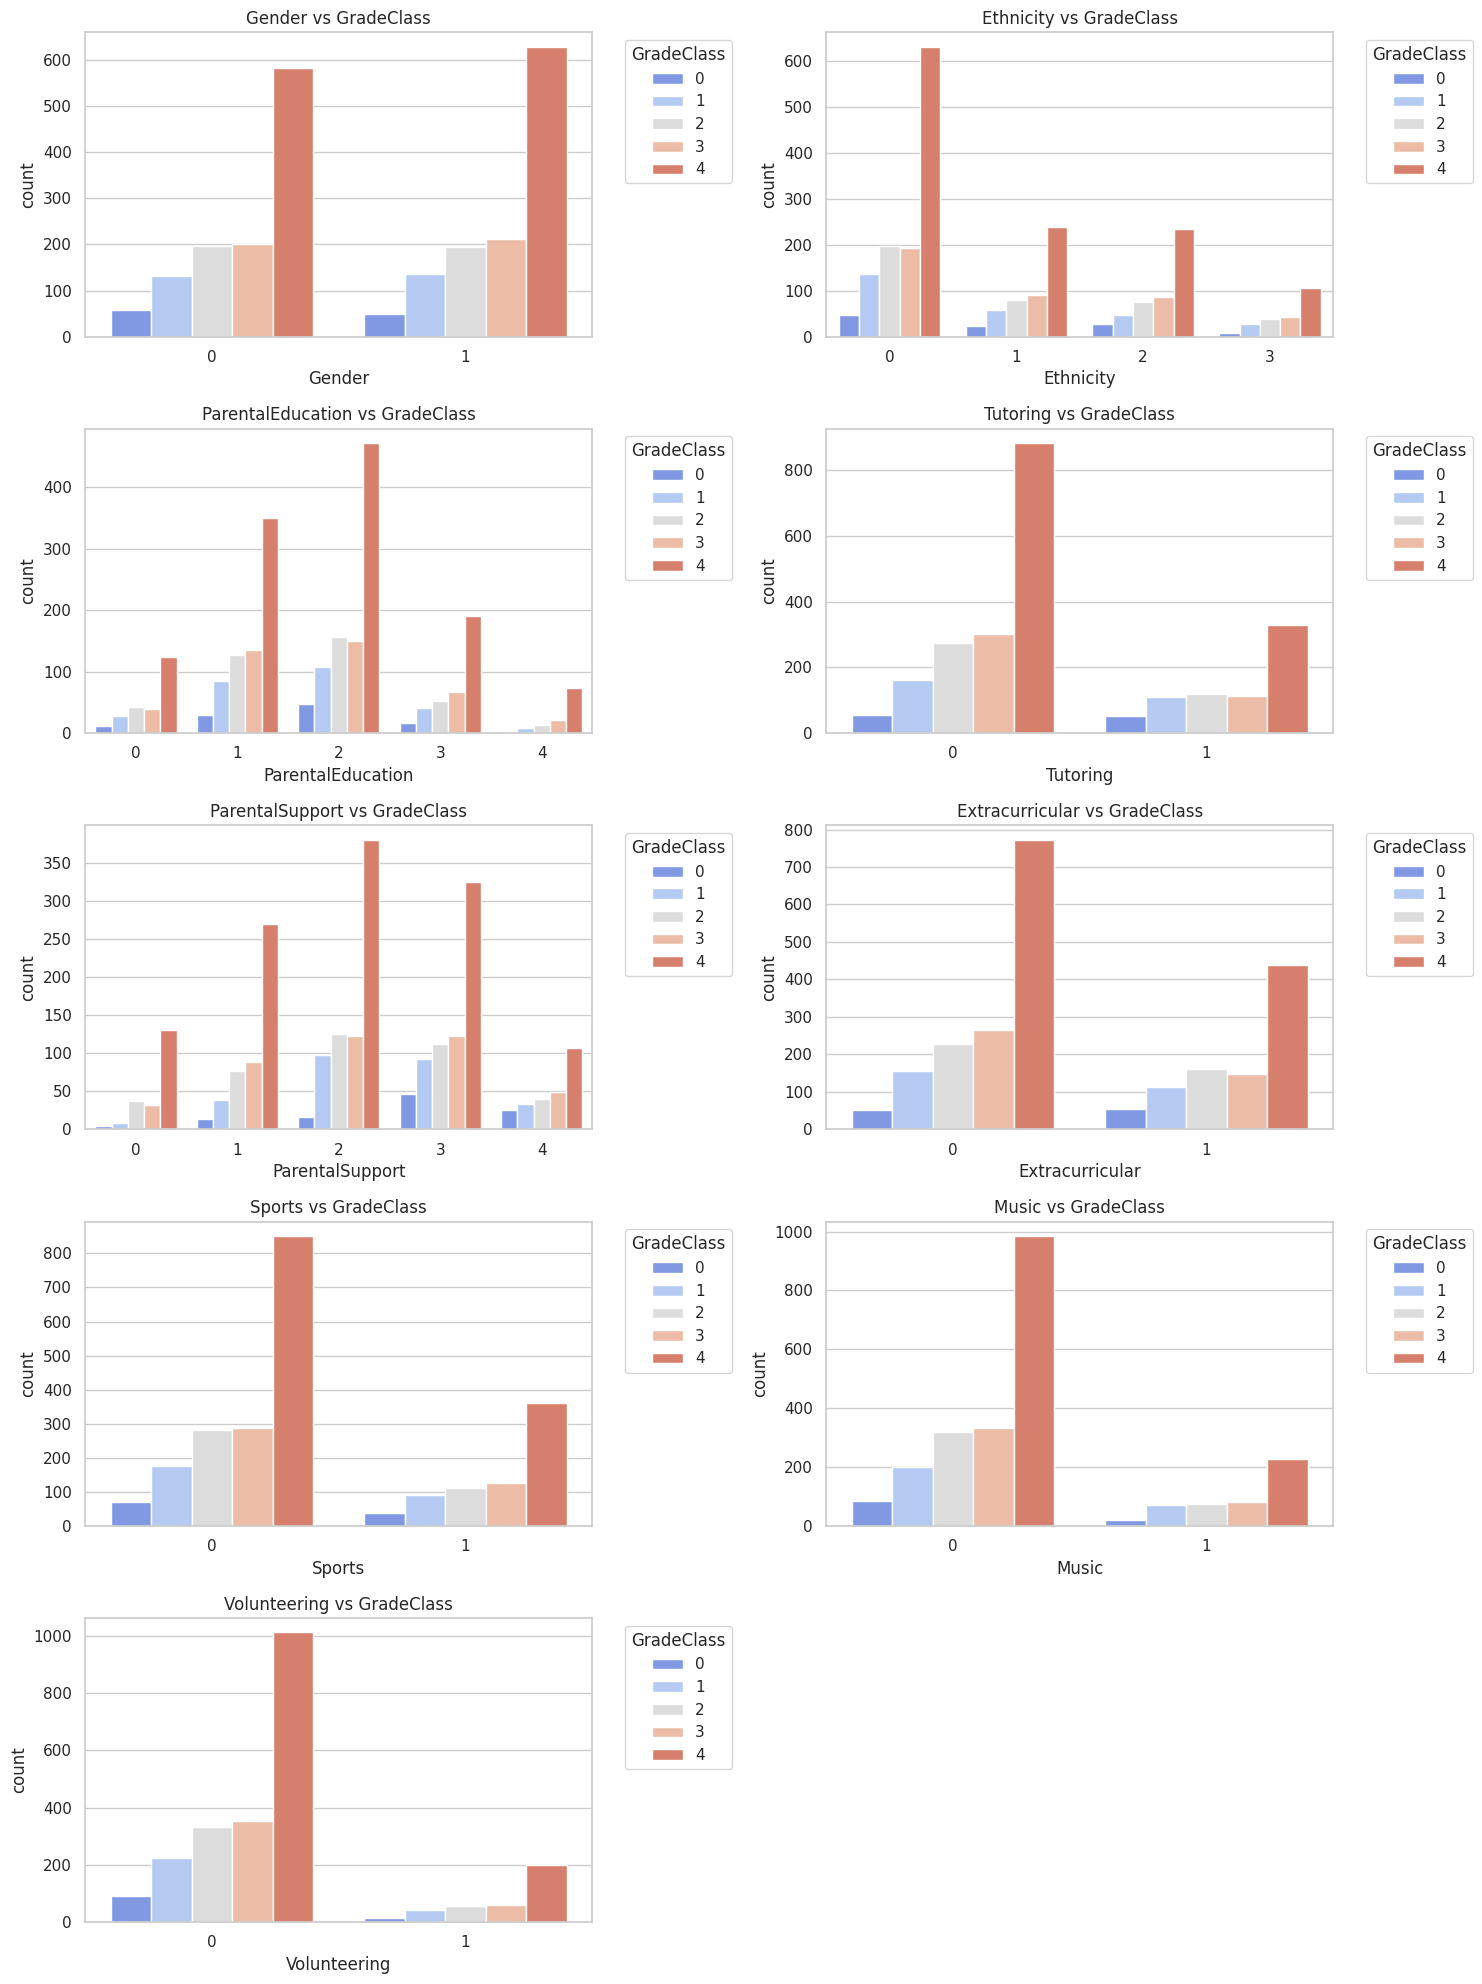

In [57]:
categorical_features = ['Gender', 'Ethnicity', 'ParentalEducation', 
                        'Tutoring', 'ParentalSupport', 'Extracurricular', 
                        'Sports', 'Music', 'Volunteering']

plt.figure(figsize=(15, 20))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(5, 2, i)
    sns.countplot(x=col, hue='GradeClass', data=df, palette='coolwarm')
    plt.title(f"{col} vs GradeClass")
    plt.legend(title='GradeClass', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
      🔢 Average GradeClass by Category
</div



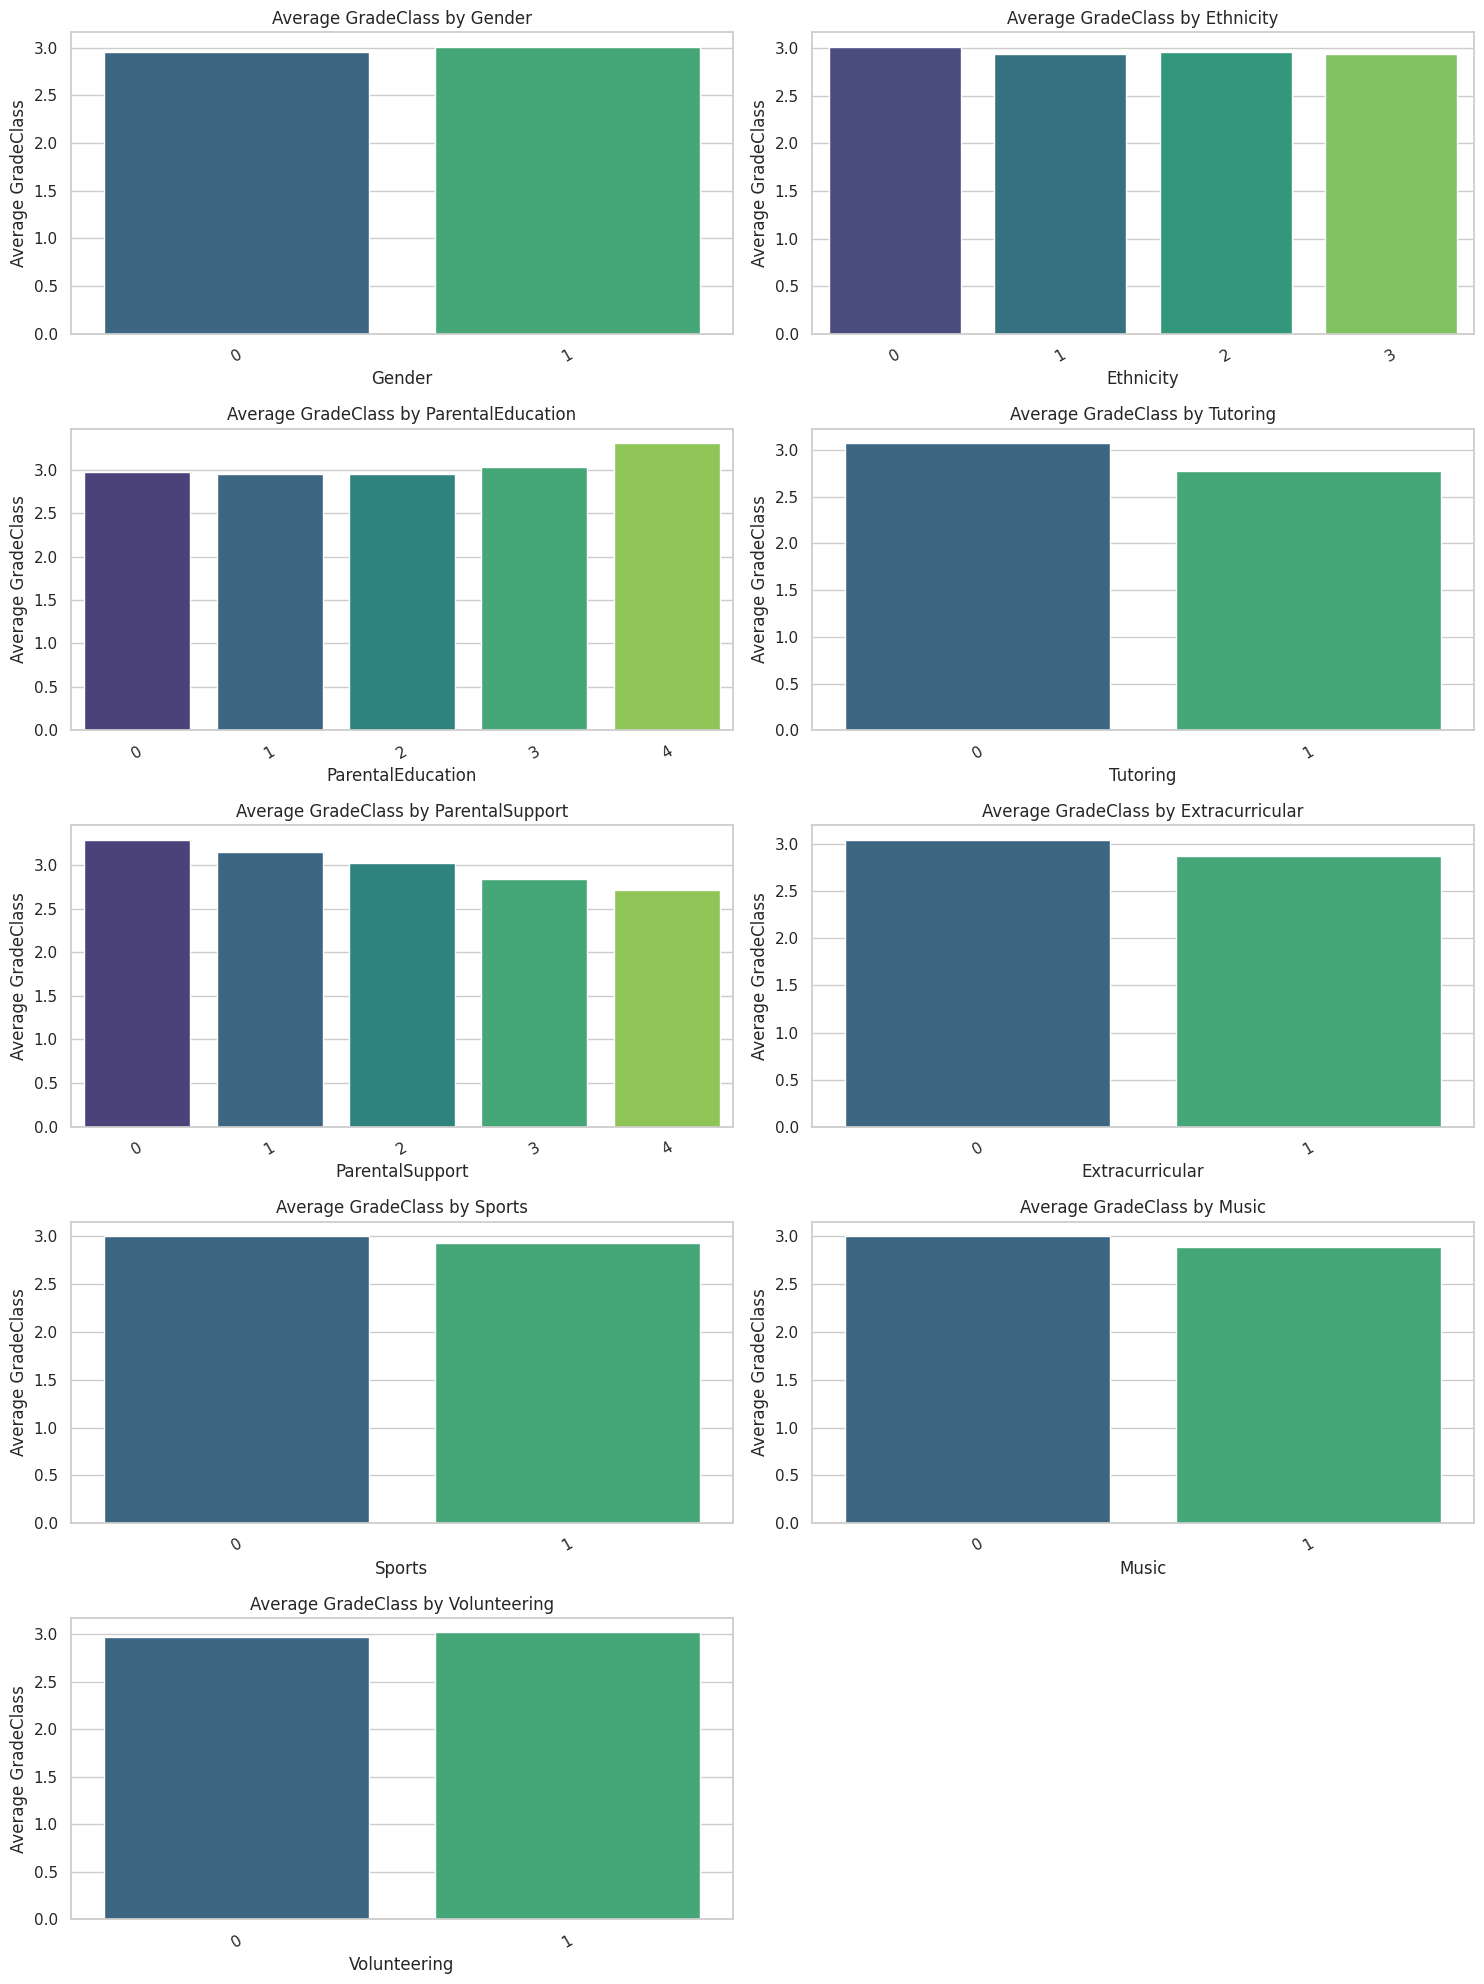

In [58]:

plt.figure(figsize=(15, 20))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(5, 2, i)
    avg_grade = df.groupby(col)['GradeClass'].mean().sort_values()
    sns.barplot(x=avg_grade.index, y=avg_grade.values, palette='viridis')
    plt.title(f"Average GradeClass by {col}")
    plt.ylabel("Average GradeClass")
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
      📊 Polished Visualizations
</div



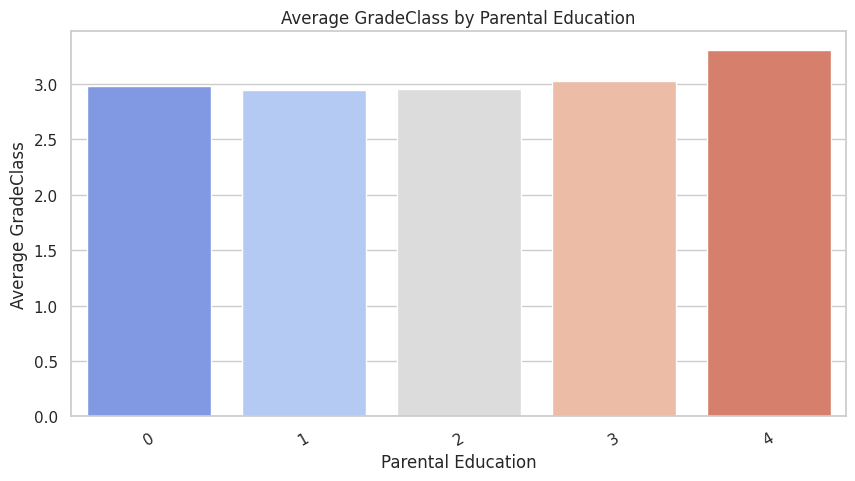

In [59]:
plt.figure(figsize=(10,5))
avg_grade_parent = df.groupby('ParentalEducation')['GradeClass'].mean().sort_values()
sns.barplot(x=avg_grade_parent.index, y=avg_grade_parent.values, palette='coolwarm')
plt.title("Average GradeClass by Parental Education")
plt.ylabel("Average GradeClass")
plt.xlabel("Parental Education")
plt.xticks(rotation=30)
plt.show()

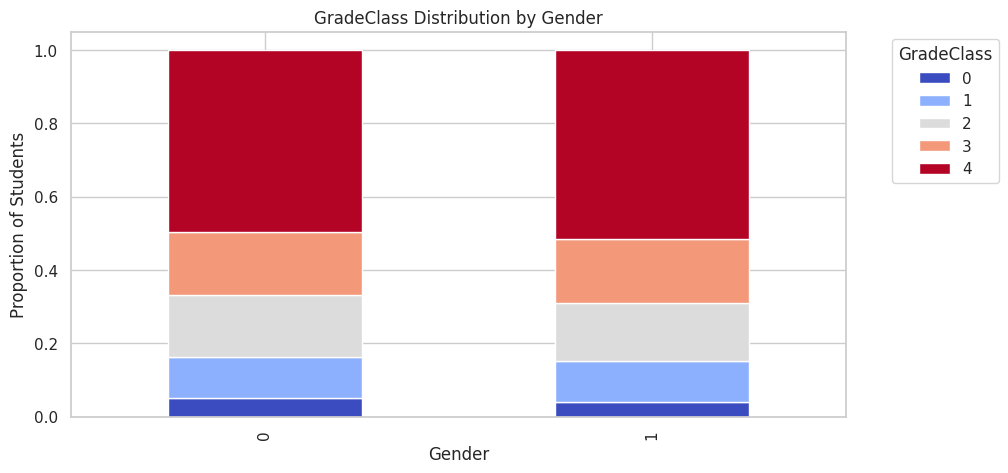

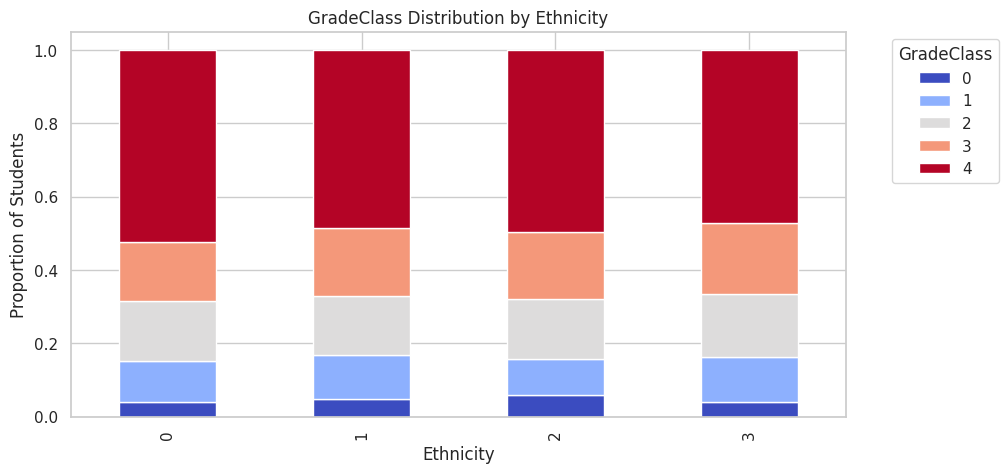

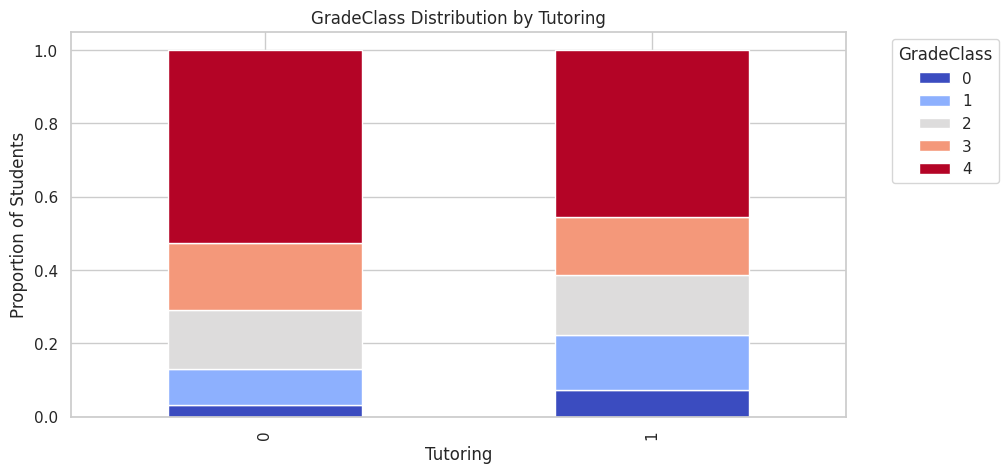

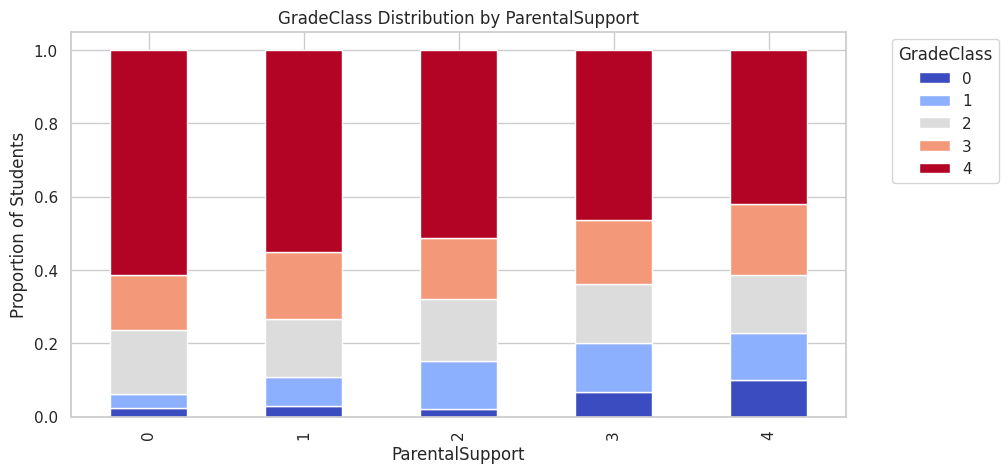

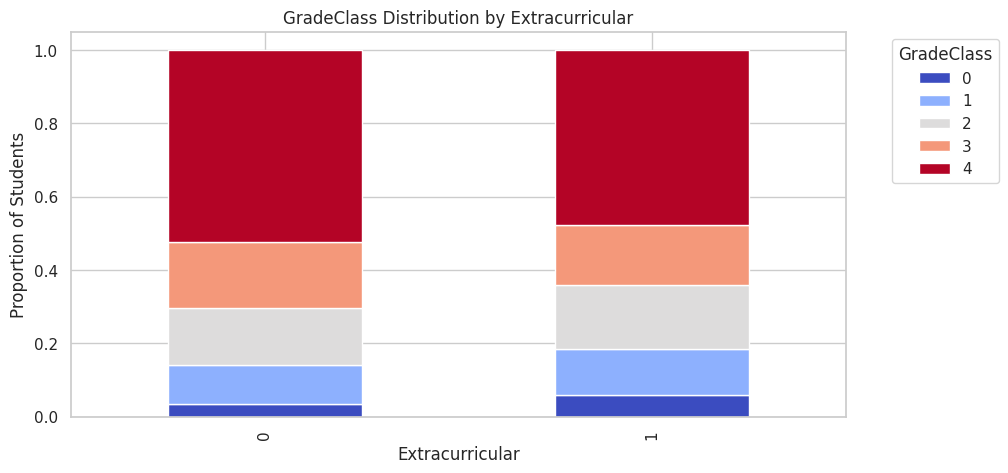

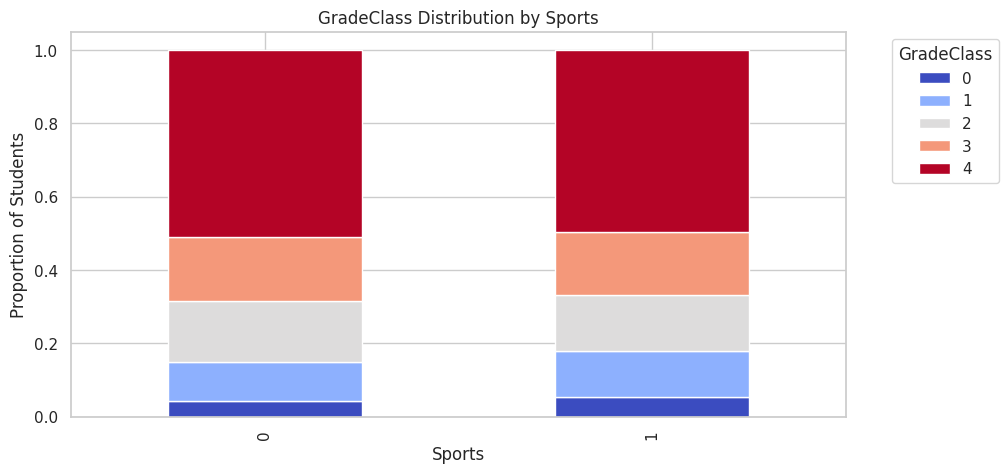

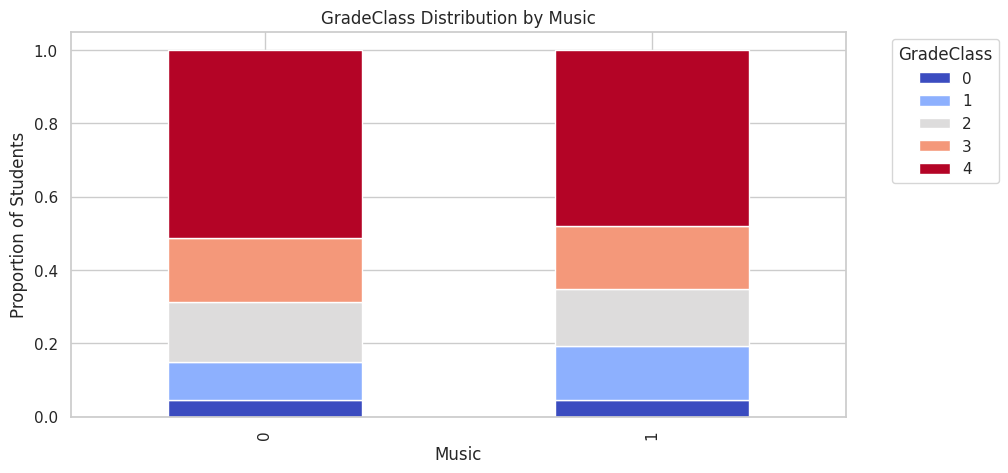

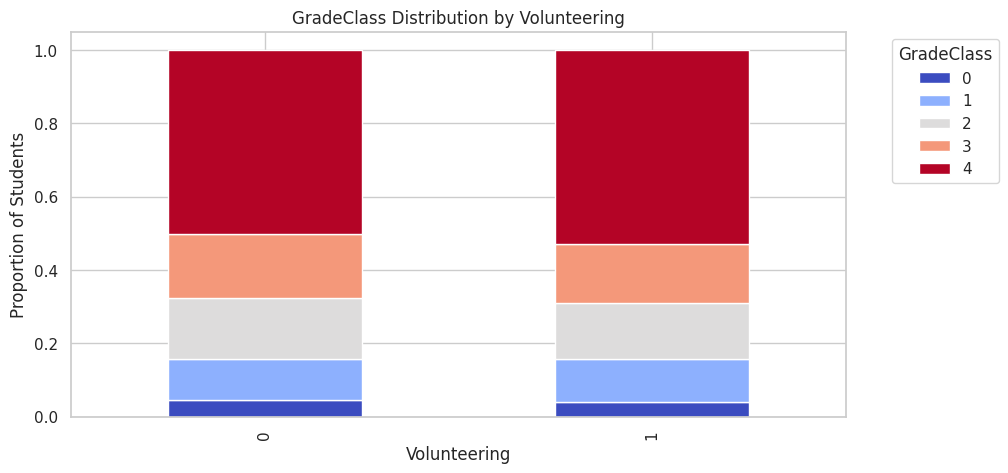

In [60]:
def stacked_barplot(feature):
    temp = pd.crosstab(df[feature], df['GradeClass'])
    temp_percent = temp.div(temp.sum(1), axis=0)
    temp_percent.plot(kind='bar', stacked=True, figsize=(10,5), colormap='coolwarm')
    plt.title(f"GradeClass Distribution by {feature}")
    plt.ylabel("Proportion of Students")
    plt.xlabel(feature)
    plt.legend(title='GradeClass', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

for col in ['Gender', 'Ethnicity', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']:
    stacked_barplot(col)

<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    🧩 Split Dataset
</div



In [61]:
X = df.drop(['StudentID', 'GPA', 'GradeClass', 'Age'], axis=1)
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    🌟 Feature Importance
</div


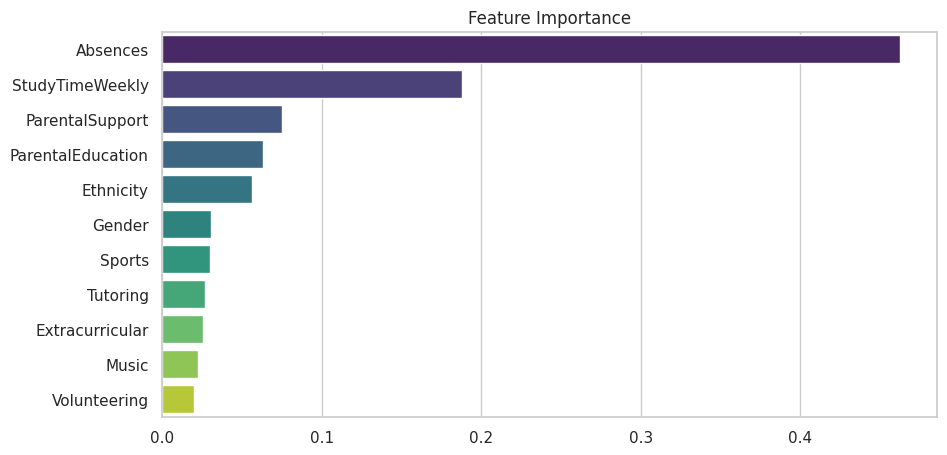

In [62]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title("Feature Importance")
plt.show()



<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    🤖 Train & Evaluate SVM
</div


In [63]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7139874739039666

Confusion Matrix:
 [[  0  13   5   2   2]
 [  0  27  17   1   4]
 [  0  12  51  16   6]
 [  0   2  16  43  25]
 [  0   1   0  15 221]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.49      0.55      0.52        49
           2       0.57      0.60      0.59        85
           3       0.56      0.50      0.53        86
           4       0.86      0.93      0.89       237

    accuracy                           0.71       479
   macro avg       0.50      0.52      0.51       479
weighted avg       0.68      0.71      0.69       479



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    🚀 Hyperparameter Tuning
</div


In [64]:
param_grid = {'C':[0.1,1,10,100,1000],'gamma':[0.0001,0.001,0.01,0.1],'kernel':['rbf','linear']}
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)


print("Best Score:", grid.best_score_)
print("Best Parameters:", grid.best_params_)

Best Score: 0.752744248356185
Best Parameters: {'C': 1, 'gamma': 0.0001, 'kernel': 'linear'}



<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    📉 Dimensionality Reduction
</div



In [67]:

X_reduced = X[['Absences','StudyTimeWeekly','ParentalSupport']]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.2, random_state=42)


svm.fit(X_train_r, y_train_r)
y_pred_r = svm.predict(X_test_r)
print("Accuracy with 3 features:", accuracy_score(y_test_r, y_pred_r))

Accuracy with 3 features: 0.6847599164926931



<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    📋 Top 5 features by importance 
</div


Top 5 Features by Importance:


,Feature,Importance
0,Absences,0.462537
1,StudyTimeWeekly,0.187999
2,ParentalSupport,0.074857
3,ParentalEducation,0.063289
4,Ethnicity,0.056104


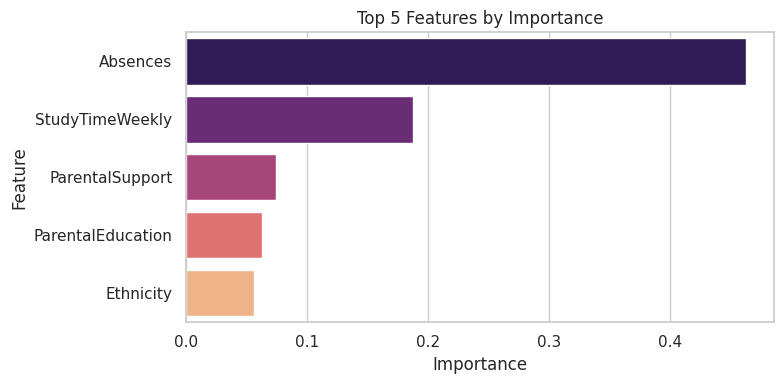

In [68]:
top_features = feature_importance.head(5).reset_index()
top_features.columns = ['Feature','Importance']
print("Top 5 Features by Importance:")
display(top_features)


plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='magma')
plt.title("Top 5 Features by Importance")
plt.tight_layout()
plt.show()


<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    📊 Predicted vs Actual GradeClass
</div



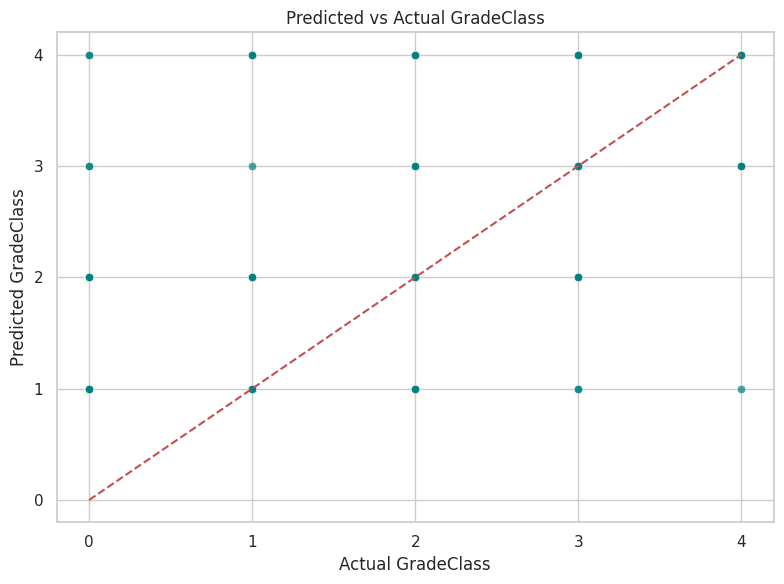

In [69]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='teal')
plt.xlabel("Actual GradeClass")
plt.ylabel("Predicted GradeClass")
plt.title("Predicted vs Actual GradeClass")
plt.xticks(sorted(df['GradeClass'].unique()))
plt.yticks(sorted(df['GradeClass'].unique()))
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.tight_layout()
plt.show()


<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    🏁 Conclusion
</div






- A Support Vector Machine (SVM) is used as the primary model (same as original).
- Top predictors of GradeClass typically include **Absences**, **StudyTimeWeekly**, and **ParentalSupport**.
- Using just the top 3 features gives a strong simplified model with slightly reduced accuracy.
- Practical takeaways for students: attend class regularly, study consistently, and seek parental support when possible.

## Final Insights 

- Academic performance is a multifactorial outcome, influenced by both academic preparation and socio-economic conditions.

- Intervention programs, such as guided test preparation and support for underperforming groups, can significantly enhance results.

- Schools and policymakers can use these insights to design targeted strategies improving overall student outcomes.


<div style="
    background-color: #1565c0; 
    color: white; 
    padding: 15px; 
    border-radius: 10px; 
    text-align: center; 
    font-size: 28px; 
    font-weight: bold;
">
    Thank You
</div
